In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [36]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (5).csv


In [37]:
dataset = pd.read_csv('Mall_Customers.csv')

In [38]:
X = dataset.iloc[:, 3:5]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [39]:
X.shape

(200, 2)

In [40]:
X.isnull().sum()

,0
Annual Income (k$),0
Spending Score (1-100),0


In [41]:
X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [42]:
wcss = []
for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, random_state = 14)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

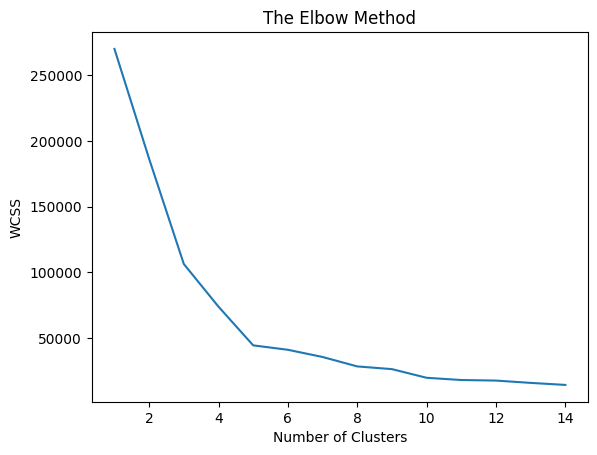

In [43]:
plt.plot(range(1, 15), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [44]:
kmeans = KMeans(n_clusters = 5, random_state = 14)
kmeans.fit(X)

KMeans(n_clusters=5, random_state=14)

In [45]:
kmeans.labels_

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 0,
       2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 0, 4, 1, 4, 1, 4,
       0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

In [46]:
hasil_kmeans = X.copy()
hasil_kmeans["cluster"] = kmeans.labels_
hasil_kmeans.head()

,Annual Income (k$),Spending Score (1-100),cluster
0,15,39,2
1,15,81,3
2,16,6,2
3,16,77,3
4,17,40,2


In [47]:
cluster_x = hasil_kmeans["cluster"].value_counts().index
cluster_y = hasil_kmeans["cluster"].value_counts().values

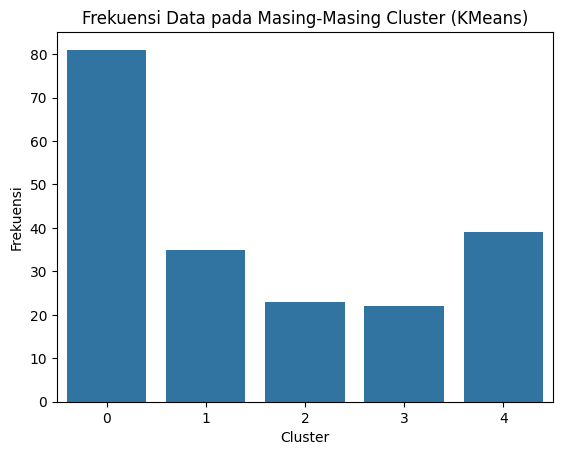

In [48]:
sns.barplot(x=cluster_x, y=cluster_y)
plt.title("Frekuensi Data pada Masing-Masing Cluster (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Frekuensi")
plt.show()

In [49]:
ann_kmeans0 = hasil_kmeans[hasil_kmeans["cluster"] == 0].iloc[:, 0]
spend_kmeans0 = hasil_kmeans[hasil_kmeans["cluster"] == 0].iloc[:, 1]
ann_kmeans1 = hasil_kmeans[hasil_kmeans["cluster"] == 1].iloc[:, 0]
spend_kmeans1 = hasil_kmeans[hasil_kmeans["cluster"] == 1].iloc[:, 1]
ann_kmeans2 = hasil_kmeans[hasil_kmeans["cluster"] == 2].iloc[:, 0]
spend_kmeans2 = hasil_kmeans[hasil_kmeans["cluster"] == 2].iloc[:, 1]
ann_kmeans3 = hasil_kmeans[hasil_kmeans["cluster"] == 3].iloc[:, 0]
spend_kmeans3 = hasil_kmeans[hasil_kmeans["cluster"] == 3].iloc[:, 1]
ann_kmeans4 = hasil_kmeans[hasil_kmeans["cluster"] == 4].iloc[:, 0]
spend_kmeans4 = hasil_kmeans[hasil_kmeans["cluster"] == 4].iloc[:, 1]

In [50]:
centroid_cluster = kmeans.cluster_centers_
centroid_cluster

array([[55.2962963 , 49.51851852],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513]])

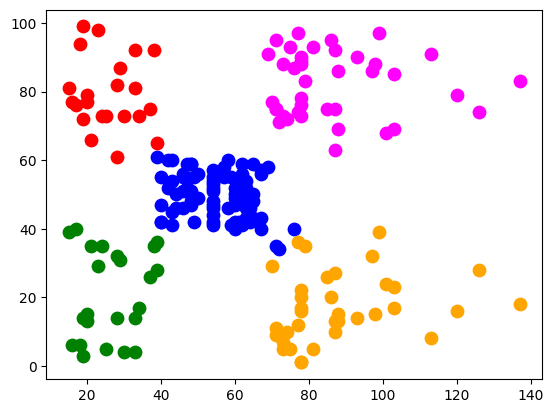

In [51]:
plt.scatter(ann_kmeans0, spend_kmeans0, s = 80, c = "blue", label = "Cluster 1")
plt.scatter(ann_kmeans1, spend_kmeans1, s = 80, c = "orange", label = "Cluster 2")
plt.scatter(ann_kmeans2, spend_kmeans2, s = 80, c = "green", label = "Cluster 3")
plt.scatter(ann_kmeans3, spend_kmeans3, s = 80, c = "red", label = "Cluster 4")
plt.scatter(ann_kmeans4, spend_kmeans4, s = 80, c = "magenta", label = "Cluster 5")

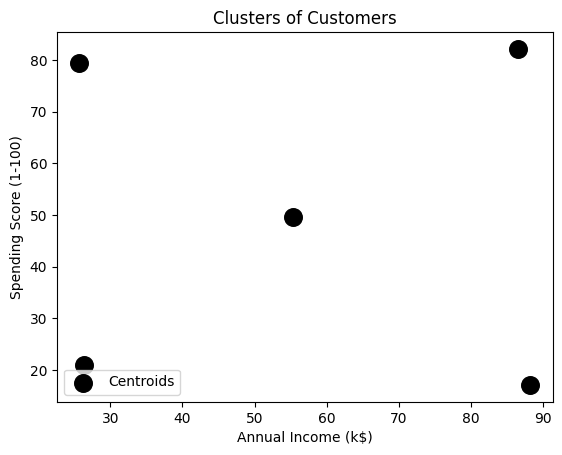

In [52]:
plt.scatter(centroid_cluster[:, 0], centroid_cluster[:, 1], s = 160, c = "black", label = "Centroids")
plt.title("Clusters of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [53]:
hasil_kmeans["CustomerID"] = dataset["CustomerID"]
hasil_kmeans.head()

,Annual Income (k$),Spending Score (1-100),cluster,CustomerID
0,15,39,2,1
1,15,81,3,2
2,16,6,2,3
3,16,77,3,4
4,17,40,2,5


In [54]:
hasil_kmeans.to_csv("Hasil Clustering Menggunakan K-Means.csv", index = False)